# Del ticket al patrón — Análisis operativo de un sistema de gestión pública

**Autor:** Gerónimo Daguerre
**Rol:** Analista Funcional
**Período analizado:** septiembre – diciembre 2025
**Dataset:** `data/tickets_anonimizado.csv` (310 peticiones, campos estructurales únicamente — sin texto libre ni datos identificables)

Este notebook reproduce el análisis y las visualizaciones del case study. El objetivo no es solo mostrar gráficos, sino documentar el razonamiento: qué pregunta responde cada vista y qué decisión de negocio podría apoyar.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

NAVY, AMBER, TEAL, TEAL_L, GREY = '#10151E', '#B8862B', '#2E6F6B', '#6FA8A4', '#C7CDD6'
plt.rcParams.update({
    'axes.edgecolor': '#CBD1D9', 'axes.labelcolor': '#4C5768',
    'text.color': '#1B2430', 'xtick.color': '#4C5768', 'ytick.color': '#4C5768'
})

df = pd.read_csv('../data/tickets_anonimizado.csv', parse_dates=['fecha_creacion'])
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticket_ref      310 non-null    str           
 1   fecha_creacion  310 non-null    datetime64[us]
 2   mes             310 non-null    str           
 3   modulo          310 non-null    str           
 4   estado          310 non-null    str           
 5   prioridad       310 non-null    str           
 6   categoria       141 non-null    str           
dtypes: datetime64[us](1), str(6)
memory usage: 17.1 KB


,ticket_ref,fecha_creacion,mes,modulo,estado,prioridad,categoria
0,TCK-0290,2025-09-22,2025-09,Gestión Economica,Validación CAIB,Normal,NaN
1,TCK-0010,2025-12-17,2025-12,Gestión Economica,Asignada,Normal,Correctivo
2,TCK-0058,2025-12-02,2025-12,Gestión Economica,Nueva,Baja,NaN
3,TCK-0061,2025-12-02,2025-12,Gestión Economica,Nueva,Baja,Evolutivo
4,TCK-0026,2025-12-11,2025-12,Planificación,En curso,Normal,NaN


## 1. Volumen y ritmo

¿El trimestre fue parejo o hubo picos? Un promedio mensual esconde estacionalidad real.

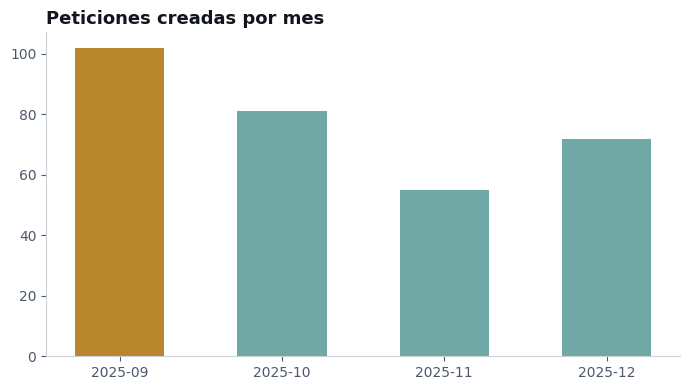

mes
2025-09    102
2025-10     81
2025-11     55
2025-12     72
Name: count, dtype: int64

Septiembre concentra 33% del volumen del trimestre.


In [2]:
monthly = df['mes'].value_counts().sort_index()
colors = [AMBER if i == 0 else TEAL_L for i in range(len(monthly))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(monthly.index, monthly.values, color=colors, width=0.55)
ax.set_title('Peticiones creadas por mes', fontsize=13, fontweight='bold', color=NAVY, loc='left')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly)
print(f"\nSeptiembre concentra {monthly.iloc[0]/monthly.sum():.0%} del volumen del trimestre.")


**Lectura:** septiembre concentra el pico (coincide con el arranque del curso escolar). Noviembre es el valle — ventana natural para trabajo evolutivo o migraciones que en septiembre sería imposible priorizar.

## 2. Dónde se concentra el trabajo

¿Todos los módulos pesan igual, o hay uno que domina el volumen?

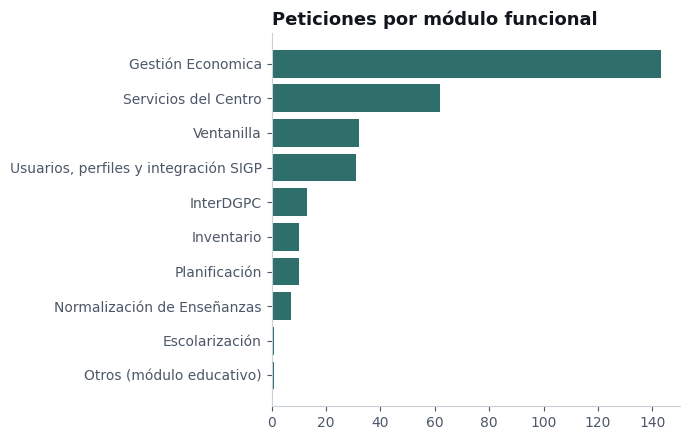

Gestión Economica concentra 46% del volumen total.


In [3]:
modulo = df['modulo'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(modulo.index, modulo.values, color=TEAL)
ax.set_title('Peticiones por módulo funcional', fontsize=13, fontweight='bold', color=NAVY, loc='left')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

top = modulo.sort_values(ascending=False)
print(f"{top.index[0]} concentra {top.iloc[0]/top.sum():.0%} del volumen total.")


**Lectura:** un módulo concentra casi la mitad del volumen — señal de que ahí vale la pena invertir en documentación de usuario o revisión de reglas de negocio antes de que sigan llegando tickets evitables.

## 3. Estado y prioridad

¿Cuánto está resuelto? ¿Las urgencias son la norma o la excepción?

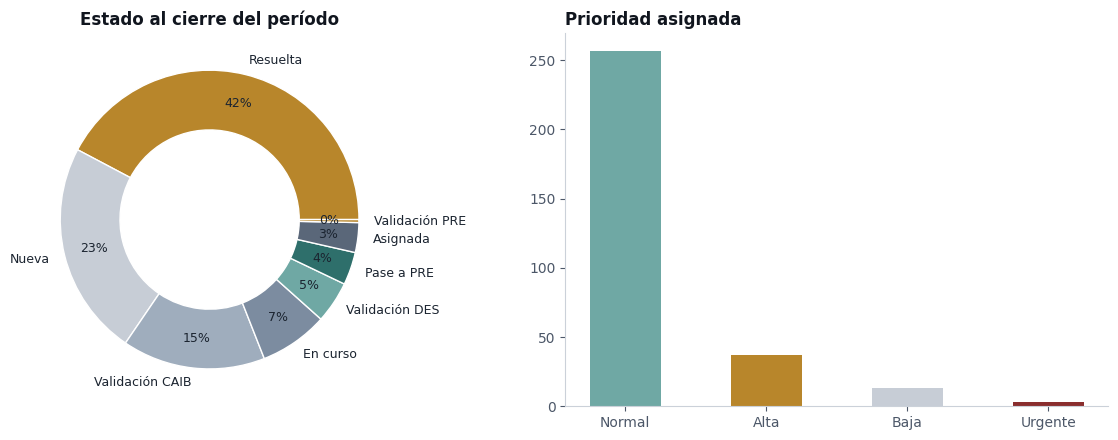

Resueltas al cierre: 42%
Prioridad Normal: 83%


In [4]:
estado = df['estado'].value_counts()
prioridad = df['prioridad'].value_counts().reindex(['Normal','Alta','Baja','Urgente'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].pie(estado.values, labels=estado.index, autopct='%1.0f%%', pctdistance=0.8,
            colors=[AMBER,'#C7CDD6','#9FADBD','#7C8CA0',TEAL_L,TEAL,'#5A6779'],
            wedgeprops=dict(width=0.4, edgecolor='white'), textprops={'fontsize':9})
axes[0].set_title('Estado al cierre del período', fontsize=12, fontweight='bold', color=NAVY)

axes[1].bar(prioridad.index, prioridad.values, color=[TEAL_L, AMBER, '#C7CDD6', '#8A2E2E'], width=0.5)
axes[1].set_title('Prioridad asignada', fontsize=12, fontweight='bold', color=NAVY, loc='left')
for s in ['top','right']: axes[1].spines[s].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Resueltas al cierre: {estado.get('Resuelta',0)/estado.sum():.0%}")
print(f"Prioridad Normal: {prioridad['Normal']/prioridad.sum():.0%}")


**Lectura:** ~42% resuelto al cierre del corte, con varias etapas de validación intermedias antes del cierre definitivo. La prioridad está fuertemente sesgada a "Normal" — las urgencias reales son la excepción.

## 4. Naturaleza del trabajo: ¿corregir o construir?

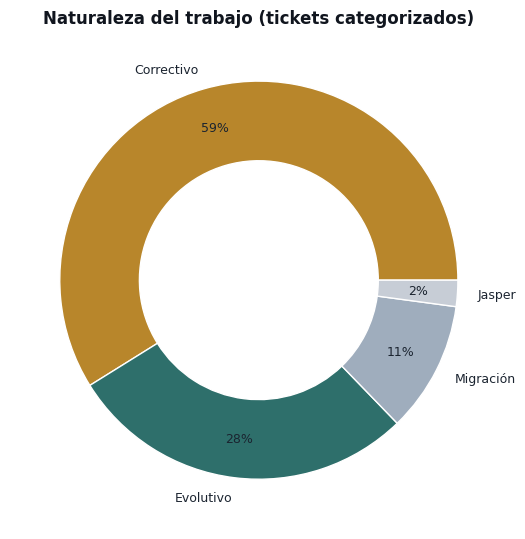

Base: 141 tickets categorizados sobre 310 totales
Correctivo: 59% · Evolutivo: 28%


In [5]:
cat = df['categoria'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(cat.values, labels=cat.index, autopct='%1.0f%%', pctdistance=0.8,
       colors=[AMBER, TEAL, '#9FADBD', '#C7CDD6'],
       wedgeprops=dict(width=0.4, edgecolor='white'), textprops={'fontsize':9})
ax.set_title('Naturaleza del trabajo (tickets categorizados)', fontsize=12, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

print(f"Base: {cat.sum()} tickets categorizados sobre {len(df)} totales")
print(f"Correctivo: {cat.get('Correctivo',0)/cat.sum():.0%} · Evolutivo: {cat.get('Evolutivo',0)/cat.sum():.0%}")


**Lectura:** el trabajo correctivo duplica al evolutivo. Cada corrección que se repite en el mismo módulo es candidata a convertirse en una mejora evolutiva que reduzca el volumen futuro, en lugar de seguir absorbiéndose caso por caso.

## 5. Conclusión

Con un export estándar de Redmine y pandas alcanza para pasar de "gestionar tickets" a leer el comportamiento de un sistema — y a poder argumentar, con datos, dónde conviene invertir el próximo esfuerzo de mejora.

---
*Ver también: [`case_study.html`](../site/index.html) para la versión narrativa de este mismo análisis.*
